# Seamless por CEIL de AWT y composición de EPT

Órdenes de `restaurants` en Chile durante la última semana completa (lunes a domingo), agrupadas por CEIL de AWT y tramo de EPT. Cada segmento representa su share sobre el total semanal de órdenes y su etiqueta muestra el Seamless de esa combinación AWT–EPT.

In [17]:
import pandas as pd
from google.cloud import bigquery
from IPython.display import display

pd.set_option("display.max_rows", None)
PROJECT_ID = "peya-chile"
bq_client = bigquery.Client(project=PROJECT_ID)

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [18]:
from pathlib import Path

query_path = Path("queries a tener a mano/seamless_by_awt_last_week.sql")
query = query_path.read_text(encoding="utf-8")

seamless_by_awt = bq_client.query(query).to_dataframe()
seamless_by_awt.head()

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,week_start,week_end,awt_ceil_min,ept_bucket,ept_bucket_start,total_orders,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-09-07,2026-09-13,0,"[1,5)",1,256,240,256,93.75,100.0
1,2026-09-07,2026-09-13,0,"[5,10)",5,58496,55642,58496,95.12,100.0
2,2026-09-07,2026-09-13,0,"[10,20)",10,111208,104913,111208,94.34,100.0
3,2026-09-07,2026-09-13,0,"[20,30)",20,37577,34830,37577,92.69,100.0
4,2026-09-07,2026-09-13,0,"[30,40)",30,9915,8646,9915,87.20,100.0


In [ ]:
if seamless_by_awt.empty:
    print("La consulta no devolvió órdenes para el período.")
else:
    week_start = pd.to_datetime(seamless_by_awt["week_start"].iloc[0]).date()
    week_end = pd.to_datetime(seamless_by_awt["week_end"].iloc[0]).date()
    print(f"Semana analizada: {week_start:%d/%m/%Y}–{week_end:%d/%m/%Y}")
    display(
        seamless_by_awt.drop(columns=["ept_bucket_start"]).head().style.format(
            {
                "total_orders": "{:,.0f}",
                "seamless_orders": "{:,.0f}",
                "classified_orders": "{:,.0f}",
                "seamless_pct": "{:.2f}%",
                "classification_coverage_pct": "{:.2f}%",
            },
            na_rep="—",
        )
    )

Semana analizada: 07/09/2026–13/09/2026


,week_start,week_end,awt_ceil_min,ept_bucket,total_orders,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-09-07,2026-09-13,0,"[1,5)",256,240,256,93.75%,100.00%
1,2026-09-07,2026-09-13,0,"[5,10)","58,496","55,642","58,496",95.12%,100.00%
2,2026-09-07,2026-09-13,0,"[10,20)","111,208","104,913","111,208",94.34%,100.00%
3,2026-09-07,2026-09-13,0,"[20,30)","37,577","34,830","37,577",92.69%,100.00%
4,2026-09-07,2026-09-13,0,"[30,40)","9,915","8,646","9,915",87.20%,100.00%
5,2026-09-07,2026-09-13,0,"[40,50)","2,376","1,757","2,376",73.95%,100.00%
6,2026-09-07,2026-09-13,0,"[50,60)",568,294,568,51.76%,100.00%
7,2026-09-07,2026-09-13,0,60+,140,37,140,26.43%,100.00%
8,2026-09-07,2026-09-13,1,"[1,5)",269,254,269,94.42%,100.00%
9,2026-09-07,2026-09-13,1,"[5,10)","26,509","25,043","26,509",94.47%,100.00%


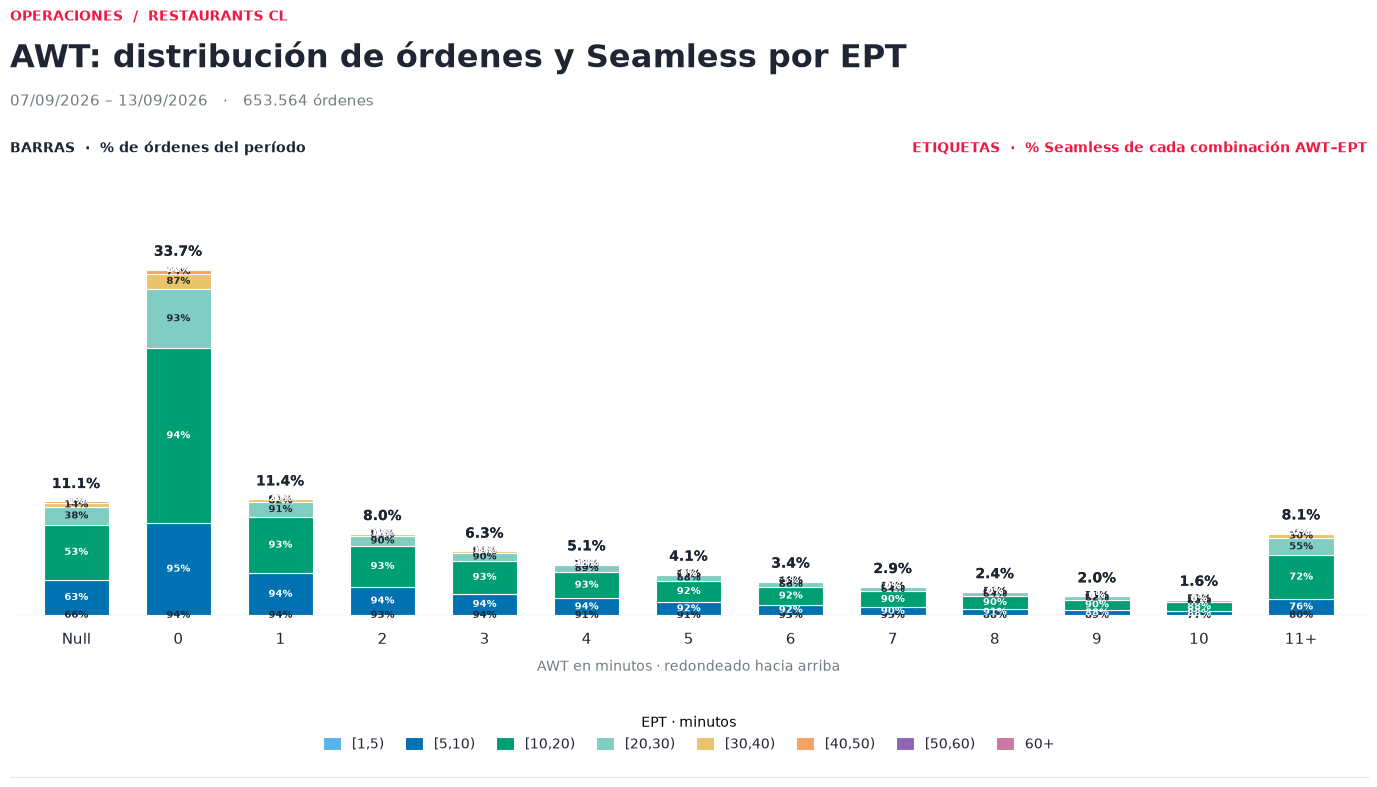

In [20]:
import matplotlib.pyplot as plt
import numpy as np

bucket_order = ["NULL"] + [str(value) for value in range(11)] + ["11+"]
plot_data = seamless_by_awt.copy()
plot_data["awt_ceil_min"] = pd.to_numeric(
    plot_data["awt_ceil_min"], errors="coerce"
)
plot_data = plot_data.loc[
    plot_data["awt_ceil_min"].isna()
    | plot_data["awt_ceil_min"].ge(0)
].copy()
has_awt = plot_data["awt_ceil_min"].notna()
plot_data["awt_bucket"] = "NULL"
plot_data.loc[has_awt, "awt_bucket"] = (
    plot_data.loc[has_awt, "awt_ceil_min"]
    .astype("Int64")
    .astype("string")
)
plot_data.loc[plot_data["awt_ceil_min"].ge(11), "awt_bucket"] = "11+"

# Consolidación defensiva: cualquier tramo con inicio >= 60 pasa a 60+.
ept_start = pd.to_numeric(plot_data["ept_bucket_start"], errors="coerce")
is_ept_60_plus = ept_start.ge(60)
plot_data.loc[is_ept_60_plus, "ept_bucket"] = "60+"
plot_data.loc[is_ept_60_plus, "ept_bucket_start"] = 60

ept_order = (
    plot_data[["ept_bucket", "ept_bucket_start"]]
    .drop_duplicates()
    .sort_values("ept_bucket_start")["ept_bucket"]
    .tolist()
)
aggregated = (
    plot_data.groupby(["awt_bucket", "ept_bucket"], observed=True)[
        ["total_orders", "seamless_orders", "classified_orders"]
    ]
    .sum()
    .reset_index()
)
order_counts = (
    aggregated.pivot(
        index="awt_bucket", columns="ept_bucket", values="total_orders"
    )
    .reindex(index=bucket_order, columns=ept_order, fill_value=0)
    .fillna(0)
)
weekly_orders = order_counts.to_numpy().sum()
ept_share = 100 * order_counts / weekly_orders

seamless_totals = (
    aggregated.groupby("awt_bucket")
    [["seamless_orders", "classified_orders"]]
    .sum()
    .reindex(bucket_order, fill_value=0)
)
seamless_pct = (
    100
    * seamless_totals["seamless_orders"]
    / seamless_totals["classified_orders"].replace(0, pd.NA)
)

import numpy as np
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# Estética inspirada en PedidosYa.
RED = "#F01945"
INK = "#202533"
MUTED = "#737987"

# Gradiente ordenado: EPT menor = claro; EPT mayor = oscuro.
# Colores diferenciados para los tramos de EPT.
ept_palette = [
    "#56B4E9",  # Celeste
    "#0072B2",  # Azul
    "#009E73",  # Verde
    "#80CDC1",  # Menta
    "#E9C46A",  # Mostaza
    "#F4A261",  # Naranjo
    "#9063B5",  # Violeta
    "#CC79A7",  # Malva
    "#8C6145",  # Café
    "#344054",  # Grafito
]

ept_colors = [
    ept_palette[i % len(ept_palette)]
    for i in range(len(ept_order))
]

fig, ax = plt.subplots(figsize=(15, 8.5), facecolor="white")
fig.subplots_adjust(left=0.055, right=0.96, top=0.76, bottom=0.25)
ax.set_facecolor("white")

ept_share.plot(
    kind="bar",
    stacked=True,
    width=0.64,
    color=ept_colors,
    edgecolor="white",
    linewidth=0.8,
    legend=False,
    ax=ax,
)

# Seamless por cada combinación AWT-EPT.
combo_seamless = (
    aggregated.assign(
        seamless_pct=lambda frame: (
            100
            * frame["seamless_orders"]
            / frame["classified_orders"].replace(0, np.nan)
        )
    )
    .pivot(
        index="ept_bucket",
        columns="awt_bucket",
        values="seamless_pct",
    )
    .reindex(index=ept_order, columns=bucket_order)
)

for ept_bucket, container in zip(ept_order, ax.containers):
    seamless_by_segment = combo_seamless.loc[ept_bucket].to_numpy(
        dtype=float, na_value=float("nan")
    )
    for bar, seamless_value in zip(container, seamless_by_segment):
        segment_height = bar.get_height()
        if segment_height <= 0 or not np.isfinite(seamless_value):
            continue
        red, green, blue, _ = bar.get_facecolor()
        luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + segment_height / 2,
            f"{seamless_value:.0f}%",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color=INK if luminance > 0.62 else "white",
            clip_on=False,
            zorder=6,
        )

bar_totals = ept_share.sum(axis=1).fillna(0)
bar_ceiling = max(float(bar_totals.max()), 1.0)

ax.set_ylim(0, bar_ceiling * 1.25)
ax.set_xlim(-0.65, len(bucket_order) - 0.35)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.set_xticks(range(len(bucket_order)))
ax.set_xticklabels(
    ["Null" if bucket == "NULL" else bucket for bucket in bucket_order],
    rotation=0,
    fontsize=11,
    color=INK,
)
ax.tick_params(axis="x", length=0, pad=12)

ax_seamless = ax.twinx()
ax_seamless.set_ylim(0, 100)

seamless_values = seamless_pct.to_numpy(
    dtype=float, na_value=float("nan")
)

# No se dibuja una línea agregada: el Seamless está en cada segmento.

# Ocultar ambos ejes Y, grillas y bordes.
for axis in (ax, ax_seamless):
    axis.set_ylabel("")
    axis.set_yticks([])
    axis.tick_params(
        axis="y",
        left=False,
        right=False,
        labelleft=False,
        labelright=False,
    )
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(False)

# Línea base discreta.
ax.axhline(0, color="#E5E7EB", linewidth=1, zorder=0)

# Cabecera.
fig.text(
    0.055, 0.95,
    "OPERACIONES  /  RESTAURANTS CL",
    fontsize=10,
    fontweight="bold",
    color=RED,
)
fig.text(
    0.055, 0.895,
    "AWT: distribución de órdenes y Seamless por EPT",
    fontsize=23,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.055, 0.85,
    f"{week_start:%d/%m/%Y} – {week_end:%d/%m/%Y}"
    f"   ·   {weekly_orders:,.0f} órdenes".replace(",", "."),
    fontsize=11,
    color=MUTED,
)

# Clave de lectura para las dos escalas.
fig.text(
    0.055, 0.795,
    "BARRAS  ·  % de órdenes del período",
    fontsize=10,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.96, 0.795,
    "ETIQUETAS  ·  % Seamless de cada combinación AWT–EPT",
    ha="right",
    fontsize=10,
    fontweight="bold",
    color=RED,
)

# Halo blanco para mejorar la lectura sin cajas visibles.
text_halo = [
    pe.withStroke(linewidth=4, foreground="white"),
    pe.Normal(),
]

# Share total de órdenes sobre cada barra.
fig.canvas.draw()

for x, value in enumerate(bar_totals):
    if value <= 0:
        continue

    ax_seamless.annotate(
        f"{value:.1f}%",
        xy=(x, value),
        xycoords=ax.transData,
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=10,
        fontweight="bold",
        path_effects=text_halo,
        zorder=11,
    )

fig.text(
    0.5075, 0.185,
    "AWT en minutos · redondeado hacia arriba",
    ha="center",
    fontsize=10,
    color=MUTED,
)

# Leyenda horizontal, ordenada de menor a mayor EPT.
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="EPT · minutos",
    loc="lower center",
    bbox_to_anchor=(0.5075, 0.075),
    ncol=min(max(len(labels), 1), 10),
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    labelcolor=INK,
    handlelength=1.3,
    handleheight=1.1,
    columnspacing=1.5,
)

fig.add_artist(
    Line2D(
        [0.055, 0.96],
        [0.06, 0.06],
        transform=fig.transFigure,
        color="#E5E7EB",
        linewidth=0.8,
    )
)
# fig.text(
#     0.055, 0.025,
#     "Seamless calculado sobre órdenes clasificadas. "
#     "Sin dato = AWT no informado. Barras y línea usan escalas independientes.",
#     fontsize=9,
#     color=MUTED,
# )

plt.show()

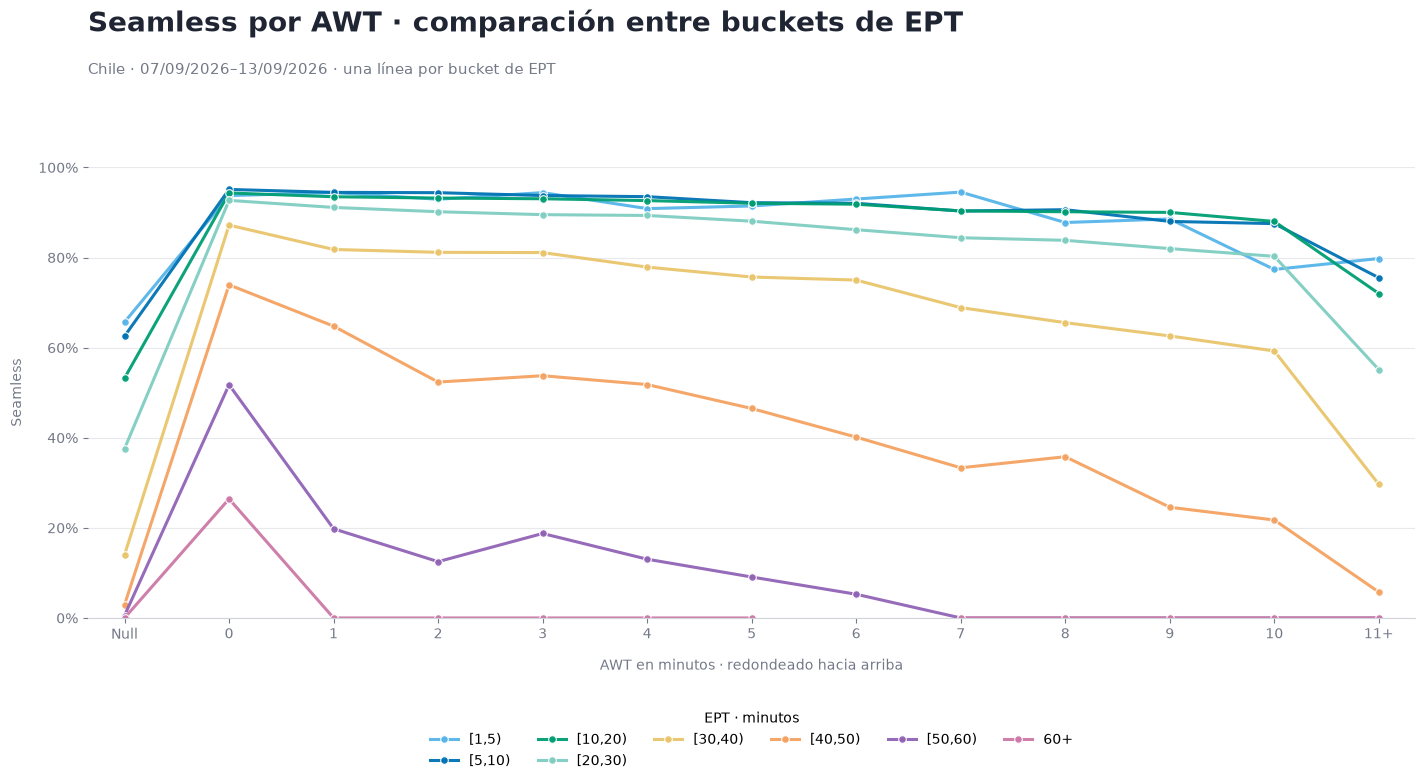

In [21]:
# Vista adicional: Seamless por combinación AWT-EPT, sin stacking.
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(15, 8.5), facecolor="white")
fig.subplots_adjust(left=0.075, right=0.96, top=0.78, bottom=0.25)
ax.set_facecolor("white")

x_positions = np.arange(len(bucket_order))
for idx, ept_bucket in enumerate(ept_order):
    seamless_values = combo_seamless.loc[ept_bucket].to_numpy(
        dtype=float, na_value=float("nan")
    )
    ax.plot(
        x_positions,
        seamless_values,
        color=ept_colors[idx],
        linewidth=2.2,
        marker="o",
        markersize=5.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        alpha=0.95,
        label=ept_bucket,
    )

ax.set_xlim(-0.35, len(bucket_order) - 0.65)
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(["Null" if bucket == "NULL" else bucket for bucket in bucket_order])
ax.set_xlabel("AWT en minutos · redondeado hacia arriba", color=MUTED, labelpad=12)
ax.set_ylabel("Seamless", color=MUTED, labelpad=10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="both", colors=MUTED)
ax.grid(axis="y", color="#E5E7EB", linewidth=0.8, alpha=0.9)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#D1D5DB")

fig.text(
    0.075, 0.94,
    "Seamless por AWT · comparación entre buckets de EPT",
    fontsize=20, fontweight="bold", color=INK,
)
fig.text(
    0.075, 0.89,
    f"Chile · {week_start:%d/%m/%Y}–{week_end:%d/%m/%Y} · una línea por bucket de EPT",
    fontsize=11, color=MUTED,
)
ax.legend(
    title="EPT · minutos",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=min(6, len(ept_order)),
    frameon=False,
)

plt.show()

## Fiestas Patrias: comparación diaria 2025 vs 2026

Compara **08–21 de septiembre de 2025** con los días transcurridos **08–13 de septiembre de 2026**, alineados por día del mes. El alcance es Chile, Restaurants, órdenes no preorder y delivery primario.

- Seamless usa sólo órdenes clasificadas; `classification_coverage_pct` permite auditar la cobertura.
- HPT y AWT10 son atribuciones ponderadas sobre órdenes totales.
- HDM muestra tanto incidencia sobre órdenes como minutos promedio entre órdenes HDM.
- EPT se presenta sin los minutos agregados por HDM.

In [22]:
from pathlib import Path
import pandas as pd
from google.cloud import bigquery
from IPython.display import display

PROJECT_ID = globals().get("PROJECT_ID", "peya-chile")
if "bq_client" not in globals():
    bq_client = bigquery.Client(project=PROJECT_ID)

FIESTAS_SQL_PATH = (
    Path("queries a tener a mano")
    / "fiestas_patrias_daily_comparison.sql"
)
fiestas_query = FIESTAS_SQL_PATH.read_text(encoding="utf-8")
fiestas_daily = bq_client.query(fiestas_query).to_dataframe()

fiestas_daily["date"] = pd.to_datetime(fiestas_daily["date"])
fiestas_daily[["year", "day"]] = fiestas_daily[["year", "day"]].astype(int)
weekday_es = {
    "Mon": "Lun", "Tue": "Mar", "Wed": "Mié",
    "Thu": "Jue", "Fri": "Vie", "Sat": "Sáb",
    "Sun": "Dom",
}
fiestas_daily["weekday"] = fiestas_daily["weekday"].map(weekday_es)

expected_days = {2025: set(range(8, 22)), 2026: set(range(8, 14))}
actual_days = {
    year: set(group["day"])
    for year, group in fiestas_daily.groupby("year")
}
if actual_days != expected_days:
    raise ValueError(f"Ventanas incompletas: {actual_days}")

low_coverage = fiestas_daily[
    fiestas_daily["classification_coverage_pct"].fillna(0).lt(99.5)
]
if not low_coverage.empty:
    print("Advertencia: hay días con cobertura Seamless menor a 99,5%.")

display(
    fiestas_daily.head().style.format(
        {
            "date": lambda value: value.strftime("%d/%m/%Y"),
            "orders": "{:,.0f}",
            "seamless_pct": "{:.2f}%",
            "classification_coverage_pct": "{:.2f}%",
            "awt_min": "{:.2f}",
            "hdm_pct": "{:.2f}%",
            "hdm_min": "{:.2f}",
            "hpt_pct": "{:.2f}%",
            "awt10_pct": "{:.2f}%",
            "ept_without_hdm_min": "{:.2f}",
            "fir_min": "{:.2f}",
        },
        na_rep="—",
    )
)

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,year,day,weekday,orders,seamless_pct,classification_coverage_pct,awt_min,hdm_pct,hdm_min,hpt_pct,awt10_pct,ept_without_hdm_min,fir_min,seamless_orders,classified_orders,awt_orders,hdm_orders,ept_orders,fir_orders,hpt_attributed_orders,awt10_attributed_orders
0,08/09/2025,2025,8,Lun,"66,835",83.47%,100.00%,2.67,0.01%,7.33,1.05%,1.32%,16.42,16.39,55783,66833,60237,9,66835,30570,703.000000,881.170000
1,09/09/2025,2025,9,Mar,"72,470",82.36%,100.00%,3.05,0.02%,8.15,1.00%,1.38%,15.81,16.66,59681,72467,64688,13,72470,33532,721.250000,1000.670000
2,10/09/2025,2025,10,Mié,"75,915",83.99%,100.00%,2.85,0.03%,6.78,0.99%,1.21%,16.22,16.20,63759,75915,68614,23,75915,35416,751.750000,921.500000
3,11/09/2025,2025,11,Jue,"82,838",82.79%,100.00%,3.22,0.03%,4.79,1.19%,1.65%,16.59,16.65,68579,82837,74629,28,82838,37984,984.750000,1370.330000
4,12/09/2025,2025,12,Vie,"97,887",82.14%,100.00%,3.08,0.09%,8.61,1.47%,1.80%,18.16,17.25,80408,97887,88657,89,97887,46217,1437.500000,1765.170000
5,13/09/2025,2025,13,Sáb,"96,732",83.26%,100.00%,2.79,0.05%,8.64,1.14%,1.56%,18.09,16.81,80542,96732,88110,50,96732,45742,1105.750000,1509.170000
6,14/09/2025,2025,14,Dom,"92,158",82.23%,100.00%,2.86,0.06%,7.19,1.18%,1.66%,17.95,16.62,75783,92158,83629,57,92158,41696,1084.500000,1526.330000
7,15/09/2025,2025,15,Lun,"71,954",83.60%,100.00%,2.96,0.14%,7.04,0.84%,1.48%,16.32,16.10,60153,71954,65010,98,71954,32781,602.500000,1064.500000
8,16/09/2025,2025,16,Mar,"78,563",82.96%,100.00%,3.14,0.13%,6.88,0.88%,1.61%,16.52,16.56,65179,78563,70765,102,78563,36109,687.750000,1267.000000
9,17/09/2025,2025,17,Mié,"71,097",82.39%,100.00%,2.87,0.15%,6.94,1.15%,1.51%,16.79,16.14,58579,71097,63678,106,71097,33267,816.250000,1075.170000


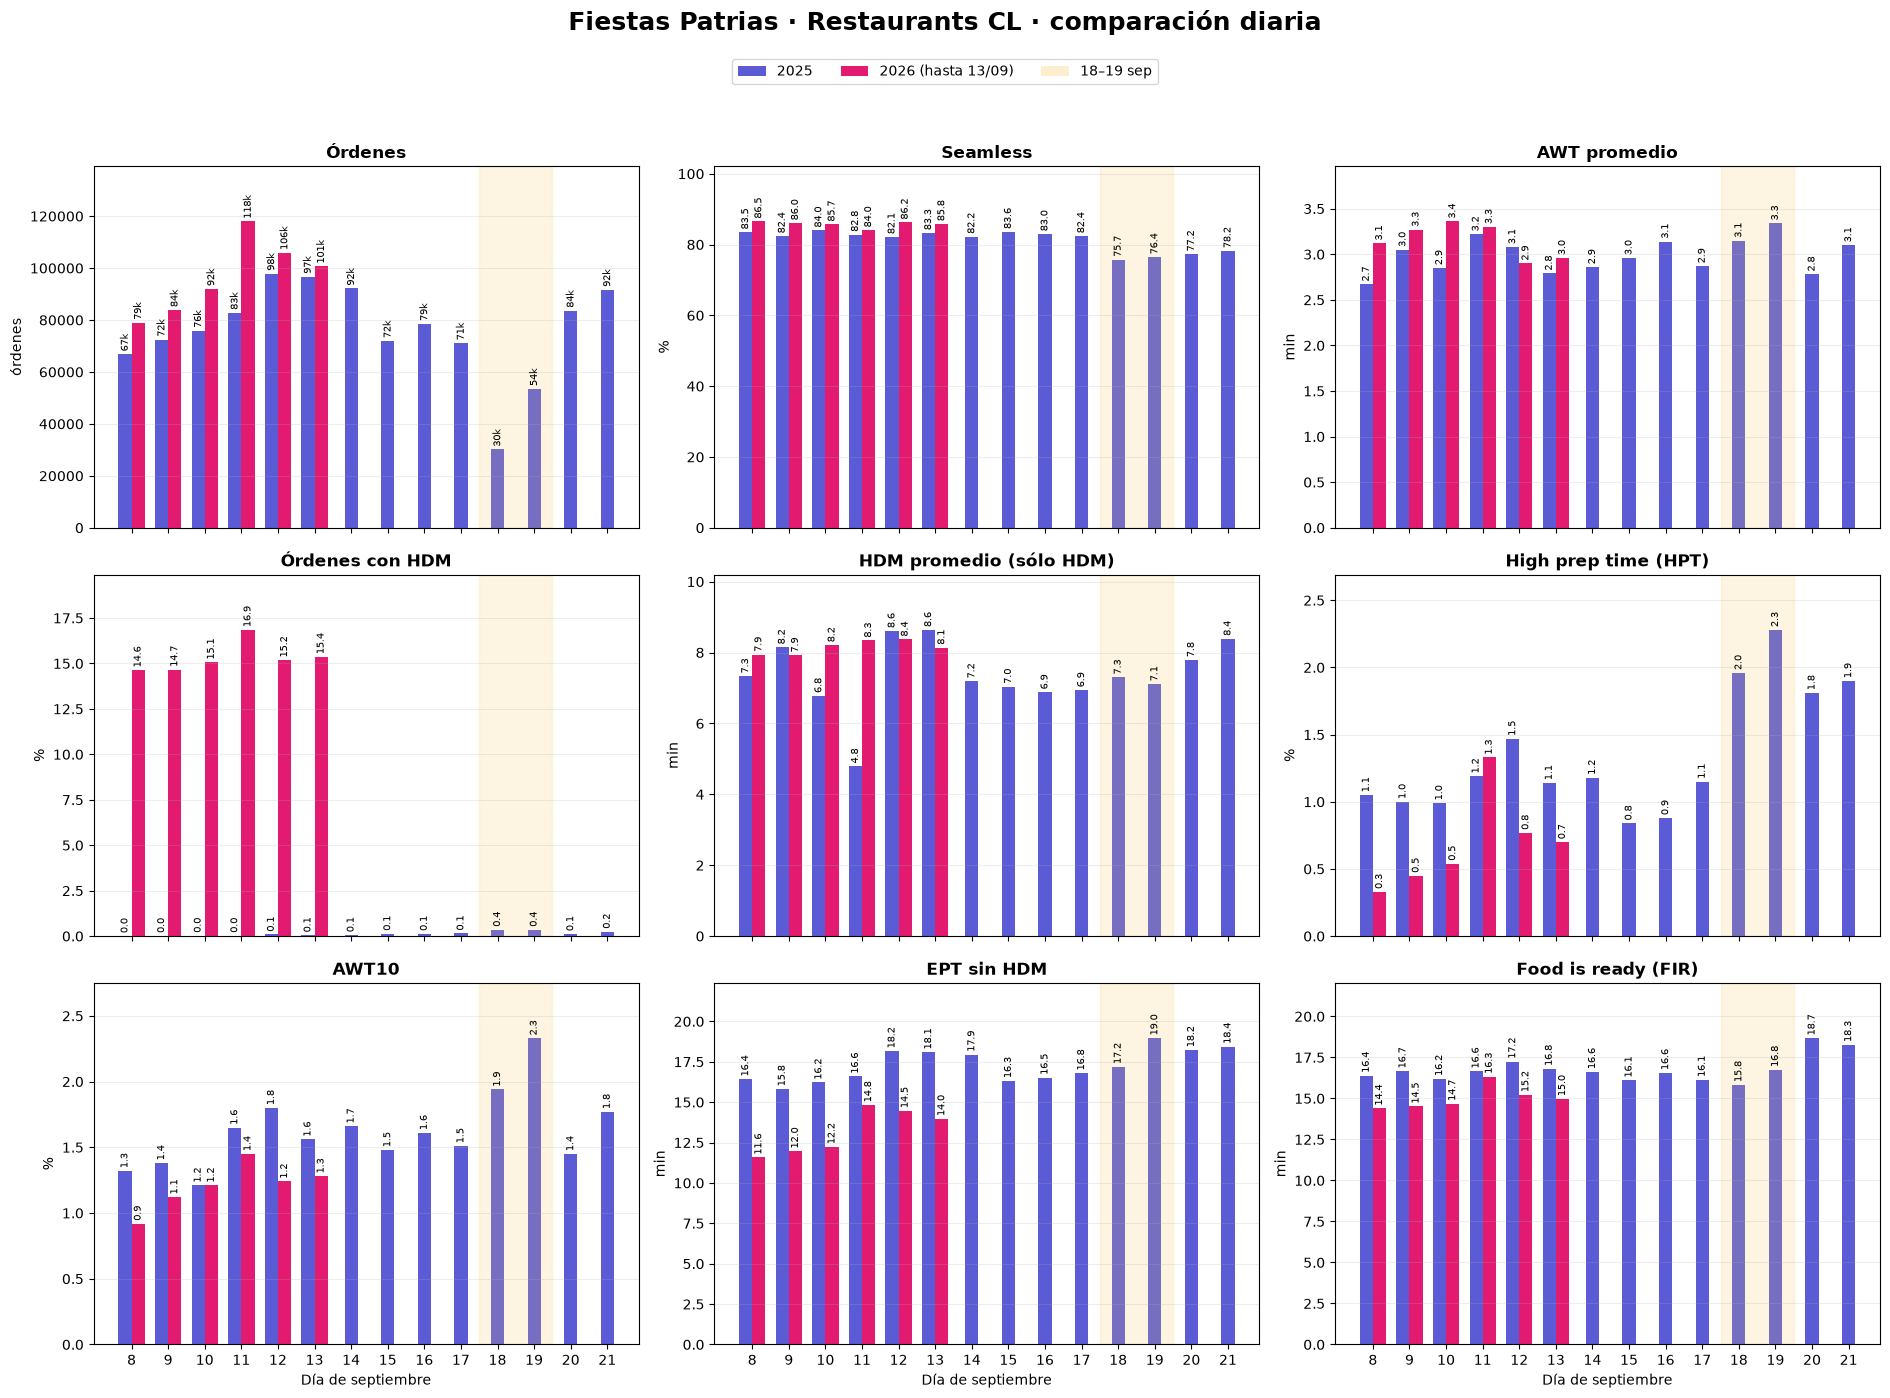

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

metric_panels = [
    ("orders", "Órdenes", "órdenes"),
    ("seamless_pct", "Seamless", "%"),
    ("awt_min", "AWT promedio", "min"),
    ("hdm_pct", "Órdenes con HDM", "%"),
    ("hdm_min", "HDM promedio (sólo HDM)", "min"),
    ("hpt_pct", "High prep time (HPT)", "%"),
    ("awt10_pct", "AWT10", "%"),
    ("ept_without_hdm_min", "EPT sin HDM", "min"),
    ("fir_min", "Food is ready (FIR)", "min"),
]

days = np.arange(8, 22)
width = 0.36
colors = {2025: "#5B5BD6", 2026: "#E21B70"}
fig, axes = plt.subplots(3, 3, figsize=(19, 14), sharex=True)

for ax, (column, title, unit) in zip(axes.flat, metric_panels):
    pivot = (
        fiestas_daily.pivot(index="day", columns="year", values=column)
        .reindex(days)
    )
    values_2025 = pivot.get(2025, pd.Series(index=days, dtype=float))
    values_2026 = pivot.get(2026, pd.Series(index=days, dtype=float))
    has_2026 = values_2026.notna().to_numpy()
    positions_2025 = np.where(has_2026, days - width / 2, days)

    bars_2025 = ax.bar(
        positions_2025, values_2025, width, color=colors[2025], label="2025"
    )
    bars_2026 = ax.bar(
        days[has_2026] + width / 2,
        values_2026.to_numpy()[has_2026],
        width,
        color=colors[2026],
        label="2026",
    )

    formatter = (
        (lambda value: f"{value / 1000:.0f}k")
        if column == "orders"
        else (lambda value: f"{value:.1f}")
    )
    for bars in (bars_2025, bars_2026):
        labels = [
            formatter(bar.get_height()) if np.isfinite(bar.get_height()) else ""
            for bar in bars
        ]
        ax.bar_label(bars, labels=labels, padding=2, fontsize=7, rotation=90)

    ax.axvspan(17.5, 19.5, color="#F6C85F", alpha=0.18)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(unit)
    finite_values = pd.concat([values_2025, values_2026]).dropna()
    upper_limit = finite_values.max() * 1.18 if not finite_values.empty else 1
    ax.set_ylim(0, upper_limit)
    ax.set_xticks(days)
    ax.grid(axis="y", alpha=0.22)

for ax in axes[-1, :]:
    ax.set_xlabel("Día de septiembre")

fig.legend(
    handles=[
        Patch(facecolor=colors[2025], label="2025"),
        Patch(facecolor=colors[2026], label="2026 (hasta 13/09)"),
        Patch(facecolor="#F6C85F", alpha=0.3, label="18–19 sep"),
    ],
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.965),
)
fig.suptitle(
    "Fiestas Patrias · Restaurants CL · comparación diaria",
    fontsize=18,
    fontweight="bold",
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

In [24]:
# Resumen comparable: sólo 08–13 de septiembre de ambos años.
common_days = fiestas_daily[fiestas_daily["day"].between(8, 13)].copy()

def weighted_metric(group, value_column, weight_column):
    weights = group[weight_column].fillna(0)
    return np.average(group[value_column].fillna(0), weights=weights)

summary_rows = []
for year, group in common_days.groupby("year"):
    total_orders = group["orders"].sum()
    summary_rows.append(
        {
            "year": year,
            "orders": total_orders,
            "seamless_pct": 100 * group["seamless_orders"].sum()
                / group["classified_orders"].sum(),
            "awt_min": weighted_metric(group, "awt_min", "awt_orders"),
            "hdm_pct": 100 * group["hdm_orders"].sum() / total_orders,
            "hdm_min": weighted_metric(group, "hdm_min", "hdm_orders"),
            "hpt_pct": 100 * group["hpt_attributed_orders"].sum()
                / total_orders,
            "awt10_pct": 100 * group["awt10_attributed_orders"].sum()
                / total_orders,
            "ept_without_hdm_min": weighted_metric(
                group, "ept_without_hdm_min", "ept_orders"
            ),
            "fir_min": weighted_metric(group, "fir_min", "fir_orders"),
        }
    )

common_summary = pd.DataFrame(summary_rows).set_index("year").T
common_summary["delta_2026_vs_2025"] = (
    common_summary[2026] - common_summary[2025]
)
display(common_summary.head().style.format("{:,.2f}"))

year,2025,2026,delta_2026_vs_2025
orders,"492,677.00","579,374.00","86,697.00"
seamless_pct,82.97,85.64,2.67
awt_min,2.95,3.15,0.20
hdm_pct,0.04,15.38,15.34
hdm_min,7.83,8.18,0.35
hpt_pct,1.16,0.73,-0.43
awt10_pct,1.51,1.22,-0.29
ept_without_hdm_min,17.00,13.34,-3.66
fir_min,16.70,15.10,-1.60


## AWT NULL: agosto 2026

Alcance: Chile, todas las verticales excepto `darkstores`, órdenes no preorder y delivery primario, entre el **01 y el 31 de agosto de 2026**.

La query detallada se conserva únicamente como apoyo para revisión manual en BigQuery. **No se ejecuta en este notebook.**

El análisis ejecutado en las celdas siguientes utiliza exclusivamente la query agrupada por `cancellation_reason` y `undispatch_reason`.

In [40]:
from pathlib import Path
import pandas as pd
from google.cloud import bigquery
from IPython.display import display

PROJECT_ID = globals().get("PROJECT_ID", "peya-chile")
if "bq_client" not in globals():
    bq_client = bigquery.Client(project=PROJECT_ID)

AWT_NULL_DETAIL_SQL_PATH = (
    Path("queries a tener a mano")
    / "awt_null_august_2026_order_detail.sql"
)
print("Query raw disponible para ejecución manual en BigQuery:")
print(AWT_NULL_DETAIL_SQL_PATH)

Query raw disponible para ejecución manual en BigQuery:
queries a tener a mano\awt_null_august_2026_order_detail.sql


### Query raw opcional

El archivo `awt_null_august_2026_order_detail.sql` queda guardado para inspeccionar órdenes puntuales. No forma parte de la ejecución ni de los resultados de este análisis.

La siguiente sección es la única que consulta BigQuery desde `sandbox`.

### Resumen por razones informadas en las fuentes

Las siguientes tablas agrupan directamente por `cancellation_reason` y `undispatch_reason`. No se combinan ni se convierten en categorías nuevas. `NULL` significa que la fuente no informó un valor para ese campo.

Una orden puede tener más de un `undispatch_reason`; en ese caso aparece una vez en cada valor distinto y los shares de esa tabla pueden sumar más de 100%.

In [41]:
from pathlib import Path
from IPython.display import display

AWT_NULL_REASONS_SQL_PATH = (
    Path("queries a tener a mano")
    / "awt_null_august_2026_reasons_grouped.sql"
)
awt_null_reasons_query = AWT_NULL_REASONS_SQL_PATH.read_text(
    encoding="utf-8"
)
awt_null_reason_stats = bq_client.query(
    awt_null_reasons_query
).to_dataframe()

stats_columns = [
    "reason_value", "orders",
    "share_of_total_orders_pct",
    "share_of_awt_null_orders_pct",
    "seamless_orders", "classified_orders",
    "seamless_pct", "classification_coverage_pct",
]
stats_format = {
    "orders": "{:,.0f}",
    "share_of_total_orders_pct": "{:.2f}%",
    "share_of_awt_null_orders_pct": "{:.2f}%",
    "seamless_orders": "{:,.0f}",
    "classified_orders": "{:,.0f}",
    "seamless_pct": "{:.2f}%",
    "classification_coverage_pct": "{:.2f}%",
}

awt_null_totals = awt_null_reason_stats[
    awt_null_reason_stats["row_type"].ne("REASON")
].copy()
cancellation_reason_summary = awt_null_reason_stats.loc[
    awt_null_reason_stats["reason_field"].eq("cancellation_reason"),
    stats_columns,
].copy()
undispatch_reason_summary = awt_null_reason_stats.loc[
    awt_null_reason_stats["reason_field"].eq("undispatch_reason"),
    stats_columns,
].copy()

print("Totales")
display(awt_null_totals.head().style.format(stats_format, na_rep="NULL"))
print("Resumen por cancellation_reason")
display(cancellation_reason_summary.head().style.format(stats_format, na_rep="NULL"))
print("Resumen por undispatch_reason")
display(undispatch_reason_summary.head().style.format(stats_format, na_rep="NULL"))

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Totales


,start_date,end_date,row_type,reason_field,reason_value,orders,share_of_total_orders_pct,share_of_awt_null_orders_pct,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-08-01,2026-08-31,TOTAL_ORDERS,NULL,NULL,"3,193,502",100.00%,NULL,"2,571,546","3,097,902",83.01%,97.01%
1,2026-08-01,2026-08-31,AWT_NULL_TOTAL,NULL,NULL,"404,493",12.67%,100.00%,"180,710","388,749",46.49%,96.11%


Resumen por cancellation_reason


,reason_value,orders,share_of_total_orders_pct,share_of_awt_null_orders_pct,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
2,NULL,"351,860",11.02%,86.99%,"179,633","339,193",52.96%,96.40%
3,ITEM_UNAVAILABLE,"9,886",0.31%,2.44%,25,"9,883",0.25%,99.97%
4,DELIVERY_ETA_TOO_LONG,"5,537",0.17%,1.37%,0,"5,333",0.00%,96.32%
5,UNABLE_TO_FIND,"5,471",0.17%,1.35%,3,"4,997",0.06%,91.34%
6,CLOSED,"5,463",0.17%,1.35%,4,"5,116",0.08%,93.65%


Resumen por undispatch_reason


,reason_value,orders,share_of_total_orders_pct,share_of_awt_null_orders_pct,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
39,NULL,"172,924",5.41%,42.75%,"88,010","157,180",55.99%,90.90%
40,Late Order Preparation,"96,928",3.04%,23.96%,"35,342","96,928",36.46%,100.00%
41,Order Issue,"23,145",0.72%,5.72%,"10,513","23,145",45.42%,100.00%
42,Issue::DispatchCourierDecline,"22,393",0.70%,5.54%,"10,731","22,393",47.92%,100.00%
43,Issue::DispatchDeliveryIgnored,"16,249",0.51%,4.02%,"7,964","16,249",49.01%,100.00%


### Resultados de agosto 2026

Sobre **3.193.502 órdenes**, **404.493** tienen AWT NULL (**12,67%**). El seamless del conjunto AWT NULL es **46,49%**, con **96,11% de cobertura**.

#### `cancellation_reason` — principales valores

| Valor fuente | Órdenes | Share AWT NULL | Seamless |
|---|---:|---:|---:|
| NULL | 351.860 | 86,99% | 52,96% |
| ITEM_UNAVAILABLE | 9.886 | 2,44% | 0,25% |
| DELIVERY_ETA_TOO_LONG | 5.537 | 1,37% | 0,00% |
| UNABLE_TO_FIND | 5.471 | 1,35% | 0,06% |
| CLOSED | 5.463 | 1,35% | 0,08% |
| MISTAKE_ERROR | 3.994 | 0,99% | 0,05% |
| LATE_DELIVERY | 3.552 | 0,88% | 0,22% |
| OUTSIDE_SERVICE_HOURS | 3.105 | 0,77% | 0,00% |
| COURIER_UNREACHABLE | 2.995 | 0,74% | 0,04% |
| NO_COURIER | 2.529 | 0,63% | 2,40% |

#### `undispatch_reason` — principales valores

| Valor fuente | Órdenes | Share AWT NULL | Seamless |
|---|---:|---:|---:|
| NULL | 172.924 | 42,75% | 55,99% |
| Late Order Preparation | 96.928 | 23,96% | 36,46% |
| Order Issue | 23.145 | 5,72% | 45,42% |
| Issue::DispatchCourierDecline | 22.393 | 5,54% | 47,92% |
| Issue::DispatchDeliveryIgnored | 16.249 | 4,02% | 49,01% |
| Issue::PickupIdleOrder | 15.440 | 3,82% | 44,34% |
| temp_offline_undispatch | 15.256 | 3,77% | 40,04% |
| Issue::DispatchDeliveryNotSeen | 13.970 | 3,45% | 49,71% |
| Rider - Not moving towards Pickup/Dropoff and Not Reachable | 8.277 | 2,05% | 33,09% |
| Accident | 5.442 | 1,35% | 43,38% |

Lectura de los datos:

- `cancellation_reason` no tiene valor en **351.860 órdenes (86,99%)**. Las **52.633 restantes (13,01%)** sí tienen una razón de cancelación informada.
- Las razones de cancelación con más órdenes son `ITEM_UNAVAILABLE` (9.886), `DELIVERY_ETA_TOO_LONG` (5.537), `UNABLE_TO_FIND` (5.471) y `CLOSED` (5.463).
- `undispatch_reason` no tiene valor en **172.924 órdenes (42,75%)**.
- `Late Order Preparation` aparece en **96.928 órdenes**, equivalentes al **23,96%** de todas las AWT NULL, y presenta **36,46% de seamless**.
- El seamless de `Late Order Preparation` es menor que el **46,49%** observado para el conjunto completo de AWT NULL.
- Una orden puede tener más de un `undispatch_reason`; estos valores describen lo registrado en la fuente y no se interpretan como una clasificación causal creada por el análisis.

La celda anterior muestra ambas tablas completas; las tablas markdown destacan solamente los valores con mayor cantidad de órdenes.

undispatch = reasignado

In [42]:
# Combinaciones fuente: cancellation_reason x undispatch_reason.
# Una orden con varios undispatch_reason puede aparecer en varias filas.
from pathlib import Path
from IPython.display import display

AWT_NULL_COMBINATIONS_SQL_PATH = (
    Path("queries a tener a mano")
    / "awt_null_august_2026_reason_combinations.sql"
)
awt_null_combinations_query = AWT_NULL_COMBINATIONS_SQL_PATH.read_text(
    encoding="utf-8"
)
awt_null_combinations = bq_client.query(
    awt_null_combinations_query
).to_dataframe()

combination_totals = awt_null_combinations.loc[
    awt_null_combinations["row_type"].ne("COMBINATION")
].copy()
combination_summary = awt_null_combinations.loc[
    awt_null_combinations["row_type"].eq("COMBINATION")
].copy()

combination_format = {
    "orders": "{:,.0f}",
    "share_of_total_orders_pct": "{:.2f}%",
    "share_of_awt_null_orders_pct": "{:.2f}%",
    "seamless_orders": "{:,.0f}",
    "classified_orders": "{:,.0f}",
    "seamless_pct": "{:.2f}%",
    "classification_coverage_pct": "{:.2f}%",
}

print("Totales")
display(combination_totals.head().style.format(combination_format, na_rep="NULL"))
print("Combinaciones cancellation_reason x undispatch_reason")
print("Nota: los shares pueden sumar más de 100% si una orden tiene varios undispatch_reason.")
display(combination_summary.head().style.format(combination_format, na_rep="NULL"))

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Totales


,start_date,end_date,row_type,cancellation_reason,undispatch_reason,orders,share_of_total_orders_pct,share_of_awt_null_orders_pct,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
0,2026-08-01,2026-08-31,TOTAL_ORDERS,NULL,NULL,"3,193,502",100.00%,NULL,"2,571,546","3,097,902",83.01%,97.01%
1,2026-08-01,2026-08-31,AWT_NULL_TOTAL,NULL,NULL,"404,493",12.67%,100.00%,"180,710","388,749",46.49%,96.11%


Combinaciones cancellation_reason x undispatch_reason
Nota: los shares pueden sumar más de 100% si una orden tiene varios undispatch_reason.


,start_date,end_date,row_type,cancellation_reason,undispatch_reason,orders,share_of_total_orders_pct,share_of_awt_null_orders_pct,seamless_orders,classified_orders,seamless_pct,classification_coverage_pct
2,2026-08-01,2026-08-31,COMBINATION,NULL,NULL,"140,443",4.40%,34.72%,"86,992","127,776",68.08%,90.98%
3,2026-08-01,2026-08-31,COMBINATION,NULL,Late Order Preparation,"88,823",2.78%,21.96%,"35,328","88,823",39.77%,100.00%
4,2026-08-01,2026-08-31,COMBINATION,NULL,Order Issue,"20,911",0.65%,5.17%,"10,506","20,911",50.24%,100.00%
5,2026-08-01,2026-08-31,COMBINATION,NULL,Issue::DispatchCourierDecline,"20,434",0.64%,5.05%,"10,717","20,434",52.45%,100.00%
6,2026-08-01,2026-08-31,COMBINATION,NULL,Issue::PickupIdleOrder,"14,947",0.47%,3.70%,"6,846","14,947",45.80%,100.00%


fail rate
reasignaciones
+10 min staffing affection


### Distribución de `rider_late` en las órdenes AWT NULL

`rider_late` es la diferencia entre la llegada del rider al vendor y el pickup originalmente programado. El campo fuente está expresado en segundos y aquí se muestra en intervalos de 5 minutos. `<0`, `60+` y `Sin dato` se mantienen visibles para que el denominador siga siendo el total de órdenes AWT NULL.

La altura de cada barra es el share del intervalo sobre **todas las órdenes AWT NULL**, no solamente sobre aquellas con `rider_late` informado.

In [43]:
from pathlib import Path

RIDER_LATE_DISTRIBUTION_SQL_PATH = (
    Path("queries a tener a mano")
    / "awt_null_august_2026_rider_late_distribution.sql"
)
rider_late_distribution_query = (
    RIDER_LATE_DISTRIBUTION_SQL_PATH.read_text(encoding="utf-8")
)
rider_late_distribution = bq_client.query(
    rider_late_distribution_query
).to_dataframe()

display(
    rider_late_distribution.head().style.format(
        {
            "orders": "{:,.0f}",
            "awt_null_orders": "{:,.0f}",
            "share_of_awt_null_orders_pct": "{:.2f}%",
        }
    )
)

c:\Users\pablo.villanueva\.gemini\antigravity\scratch\bigquery_pipeline\github primer repo\lower-ept-y-awt\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,start_date,end_date,bucket_order,rider_late_bucket_minutes,orders,awt_null_orders,share_of_awt_null_orders_pct
0,2026-08-01,2026-08-31,-1,Sin dato,"33,839","404,493",8.37%
1,2026-08-01,2026-08-31,0,<0,"29,581","404,493",7.31%
2,2026-08-01,2026-08-31,1,0-5,"12,834","404,493",3.17%
3,2026-08-01,2026-08-31,2,5-10,"53,082","404,493",13.12%
4,2026-08-01,2026-08-31,3,10-15,"93,056","404,493",23.01%


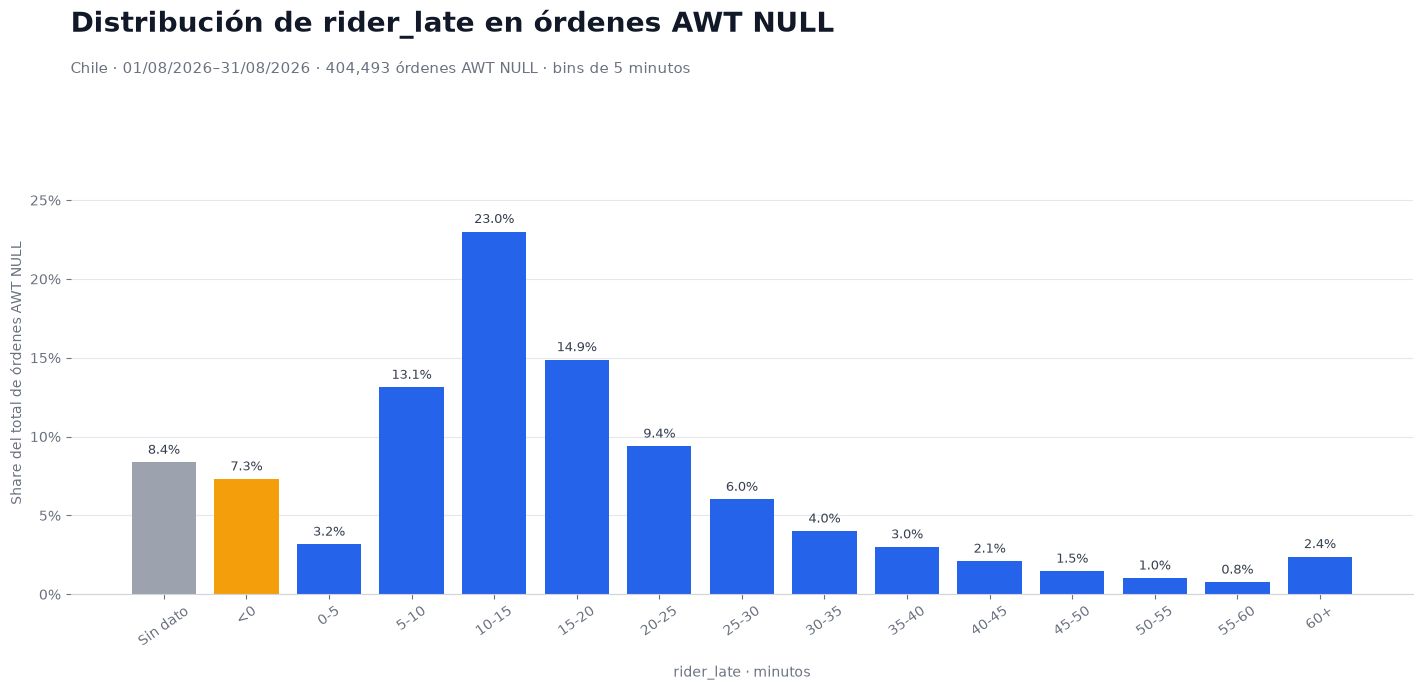

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

rider_late_plot = rider_late_distribution.sort_values("bucket_order").copy()
labels = rider_late_plot["rider_late_bucket_minutes"].tolist()
shares = rider_late_plot["share_of_awt_null_orders_pct"].astype(float)
colors = [
    "#9CA3AF" if label == "Sin dato"
    else "#F59E0B" if label == "<0"
    else "#2563EB"
    for label in labels
]

fig, ax = plt.subplots(figsize=(15, 7.5), facecolor="white")
fig.subplots_adjust(left=0.075, right=0.97, top=0.78, bottom=0.19)
bars = ax.bar(labels, shares, color=colors, width=0.78)

ax.bar_label(
    bars,
    labels=[f"{value:.1f}%" for value in shares],
    padding=4,
    fontsize=9,
    color="#374151",
)
ax.set_ylim(0, max(shares) * 1.22)
ax.set_xlabel("rider_late · minutos", color="#6B7280", labelpad=12)
ax.set_ylabel("Share del total de órdenes AWT NULL", color="#6B7280")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="x", rotation=35, colors="#6B7280")
ax.tick_params(axis="y", colors="#6B7280")
ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#D1D5DB")

start_date = pd.to_datetime(rider_late_plot["start_date"].iloc[0]).date()
end_date = pd.to_datetime(rider_late_plot["end_date"].iloc[0]).date()
awt_null_total = int(rider_late_plot["awt_null_orders"].iloc[0])
fig.text(
    0.075, 0.94,
    "Distribución de rider_late en órdenes AWT NULL",
    fontsize=20, fontweight="bold", color="#111827",
)
fig.text(
    0.075, 0.885,
    f"Chile · {start_date:%d/%m/%Y}–{end_date:%d/%m/%Y} · "
    f"{awt_null_total:,.0f} órdenes AWT NULL · bins de 5 minutos",
    fontsize=11, color="#6B7280",
)

plt.show()

### Resumen general de AWT NULL

Las barras comparan el share de órdenes AWT NULL que presenta cada señal disponible. No son categorías excluyentes entre barras: una misma orden puede tener cancelación, undispatch y `rider_late` informado. Dentro de cada barra, en cambio, los segmentos no se superponen.

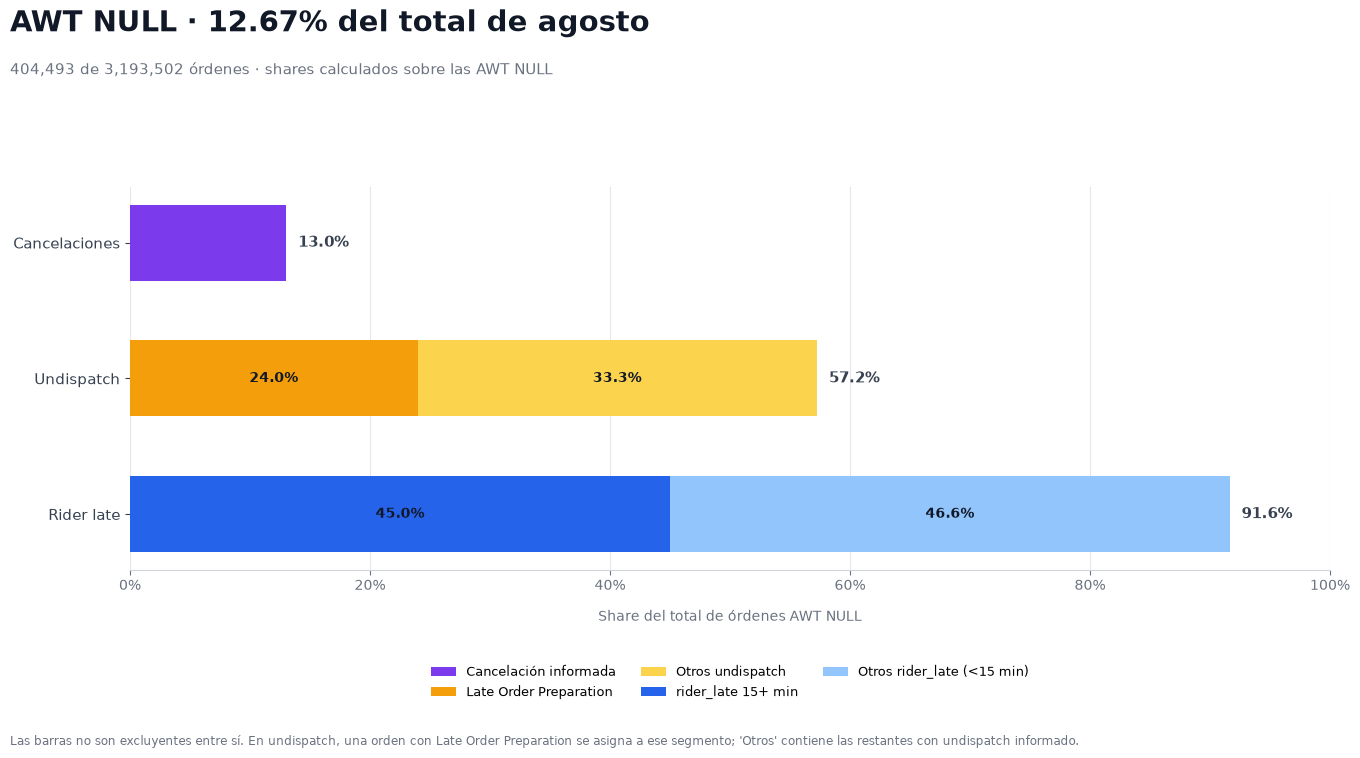

In [45]:
# Resumen de las señales ya consultadas; no ejecuta una query adicional.
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

total_august_orders = int(
    awt_null_reason_stats.loc[
        awt_null_reason_stats["row_type"].eq("TOTAL_ORDERS"), "orders"
    ].iloc[0]
)
awt_null_orders = int(
    awt_null_reason_stats.loc[
        awt_null_reason_stats["row_type"].eq("AWT_NULL_TOTAL"), "orders"
    ].iloc[0]
)
awt_null_share_total = 100 * awt_null_orders / total_august_orders

reason_rows = awt_null_reason_stats.loc[
    awt_null_reason_stats["row_type"].eq("REASON")
].copy()

cancellation_without_reason = int(
    reason_rows.loc[
        reason_rows["reason_field"].eq("cancellation_reason")
        & reason_rows["reason_value"].isna(),
        "orders",
    ].sum()
)
cancellation_orders = awt_null_orders - cancellation_without_reason

undispatch_without_reason = int(
    reason_rows.loc[
        reason_rows["reason_field"].eq("undispatch_reason")
        & reason_rows["reason_value"].isna(),
        "orders",
    ].sum()
)
undispatch_orders = awt_null_orders - undispatch_without_reason
late_prep_orders = int(
    reason_rows.loc[
        reason_rows["reason_field"].eq("undispatch_reason")
        & reason_rows["reason_value"].eq("Late Order Preparation"),
        "orders",
    ].sum()
)
other_undispatch_orders = undispatch_orders - late_prep_orders

rider_late_informed_orders = int(
    rider_late_distribution.loc[
        rider_late_distribution["bucket_order"].ge(0), "orders"
    ].sum()
)
rider_late_15_plus_orders = int(
    rider_late_distribution.loc[
        rider_late_distribution["bucket_order"].ge(4), "orders"
    ].sum()
)
other_rider_late_orders = (
    rider_late_informed_orders - rider_late_15_plus_orders
)

labels = ["Cancelaciones", "Undispatch", "Rider late"]
segment_counts = {
    "Cancelación informada": [cancellation_orders, 0, 0],
    "Late Order Preparation": [0, late_prep_orders, 0],
    "Otros undispatch": [0, other_undispatch_orders, 0],
    "rider_late 15+ min": [0, 0, rider_late_15_plus_orders],
    "Otros rider_late (<15 min)": [0, 0, other_rider_late_orders],
}
segment_colors = {
    "Cancelación informada": "#7C3AED",
    "Late Order Preparation": "#F59E0B",
    "Otros undispatch": "#FCD34D",
    "rider_late 15+ min": "#2563EB",
    "Otros rider_late (<15 min)": "#93C5FD",
}

fig, ax = plt.subplots(figsize=(15, 7.8), facecolor="white")
fig.subplots_adjust(left=0.16, right=0.96, top=0.74, bottom=0.25)
left = [0.0, 0.0, 0.0]
for segment_name, counts in segment_counts.items():
    shares = [100 * count / awt_null_orders for count in counts]
    bars = ax.barh(
        labels, shares, left=left, height=0.56,
        color=segment_colors[segment_name], label=segment_name,
    )
    for bar, value in zip(bars, shares):
        if value >= 3 and segment_name != "Cancelación informada":
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                ha="center", va="center", fontsize=10,
                fontweight="bold", color="#111827",
            )
    left = [current + value for current, value in zip(left, shares)]

ax.invert_yaxis()

for row_index, total_share in enumerate(left):
    ax.text(
        total_share + 1.0, row_index, f"{total_share:.1f}%",
        va="center", fontsize=11, fontweight="bold", color="#374151",
    )

ax.set_xlim(0, 100)
ax.set_xlabel("Share del total de órdenes AWT NULL", color="#6B7280", labelpad=12)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="x", colors="#6B7280")
ax.tick_params(axis="y", colors="#374151", labelsize=11)
ax.grid(axis="x", color="#E5E7EB", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#D1D5DB")

fig.text(
    0.08, 0.94,
    f"AWT NULL · {awt_null_share_total:.2f}% del total de agosto",
    fontsize=21, fontweight="bold", color="#111827",
)
fig.text(
    0.08, 0.885,
    f"{awt_null_orders:,.0f} de {total_august_orders:,.0f} órdenes · "
    "shares calculados sobre las AWT NULL",
    fontsize=11, color="#6B7280",
)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=3, frameon=False, fontsize=9,
)
fig.text(
    0.08, 0.025,
    "Las barras no son excluyentes entre sí. En undispatch, una orden con Late Order Preparation "
    "se asigna a ese segmento; 'Otros' contiene las restantes con undispatch informado.",
    fontsize=8.5, color="#6B7280",
)

plt.show()